In [1]:
'''
IMPORTS
'''

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

In [2]:
filename = '2015.csv' #Change to filename .csv

csv_path = "../data/" + filename
df = pd.read_csv(csv_path)

In [3]:
df.head()

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176


In [4]:
'''
General Shape
'''

print("Shape:", df.shape)
print("\nColumn Types:")
display(df.dtypes)

Shape: (158, 12)

Column Types:


Country                           object
Region                            object
Happiness Rank                     int64
Happiness Score                  float64
Standard Error                   float64
Economy (GDP per Capita)         float64
Family                           float64
Health (Life Expectancy)         float64
Freedom                          float64
Trust (Government Corruption)    float64
Generosity                       float64
Dystopia Residual                float64
dtype: object

In [5]:
'''
Missing Values
'''
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
}).sort_values("missing_percent", ascending=False)

display(missing_summary)


,missing_count,missing_percent
Country,0,0.0
Region,0,0.0
Happiness Rank,0,0.0
Happiness Score,0,0.0
Standard Error,0,0.0
Economy (GDP per Capita),0,0.0
Family,0,0.0
Health (Life Expectancy),0,0.0
Freedom,0,0.0
Trust (Government Corruption),0,0.0


In [6]:
print("Duplicate rows:", df.duplicated().sum())

constant_cols = [c for c in df.columns if df[c].nunique(dropna=False) == 1]
print("Columns with one unique value:", constant_cols)

high_missing = missing_summary[missing_summary["missing_percent"] > 50]
print("Columns with >50% missing:")
display(high_missing)

Duplicate rows: 0
Columns with one unique value: []
Columns with >50% missing:


,missing_count,missing_percent


In [7]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()

numeric_cols, categorical_cols

(['Happiness Rank',
  'Happiness Score',
  'Standard Error',
  'Economy (GDP per Capita)',
  'Family',
  'Health (Life Expectancy)',
  'Freedom',
  'Trust (Government Corruption)',
  'Generosity',
  'Dystopia Residual'],
 ['Country', 'Region'])

In [8]:
if categorical_cols:
    cat_col = categorical_cols[0]
    cat_counts = df[cat_col].value_counts(dropna=False)
    cat_percent = df[cat_col].value_counts(normalize=True, dropna=False) * 100

    cat_summary = pd.DataFrame({
        "count": cat_counts,
        "percent": cat_percent.round(2)
    })

    display(cat_summary)


,count,percent
Country,,
Switzerland,1,0.63
Iceland,1,0.63
Denmark,1,0.63
Norway,1,0.63
Canada,1,0.63
...,...,...
Rwanda,1,0.63
Benin,1,0.63
Syria,1,0.63


In [9]:
def numeric_summary(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    return {
        "min": series.min(),
        "max": series.max(),
        "mean": series.mean(),
        "median": series.median(),
        "mode": series.mode().iloc[0] if not series.mode().empty else np.nan,
        "std": series.std(),
        "IQR": iqr,
        "outliers_1.5IQR": ((series < q1 - 1.5*iqr) | (series > q3 + 1.5*iqr)).sum()
    }

num_stats = {col: numeric_summary(df[col].dropna()) for col in numeric_cols[:2]}
pd.DataFrame(num_stats)


,Happiness Rank,Happiness Score
min,1.000000,2.839000
max,158.000000,7.587000
mean,79.493671,5.375734
median,79.500000,5.232500
mode,82.000000,5.192000
std,45.754363,1.145010
IQR,78.500000,1.717750
outliers_1.5IQR,0.000000,0.000000


**VISUALIZATIONS**

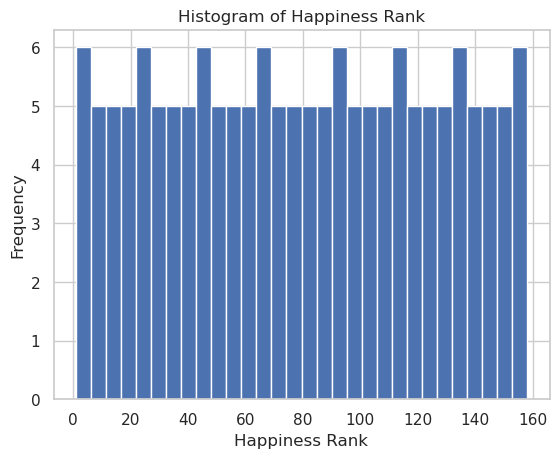

In [10]:
#HISTOGRAM
df[numeric_cols[0]].hist(bins=30)
plt.title(f"Histogram of {numeric_cols[0]}")
plt.xlabel(numeric_cols[0])
plt.ylabel("Frequency")
plt.show()

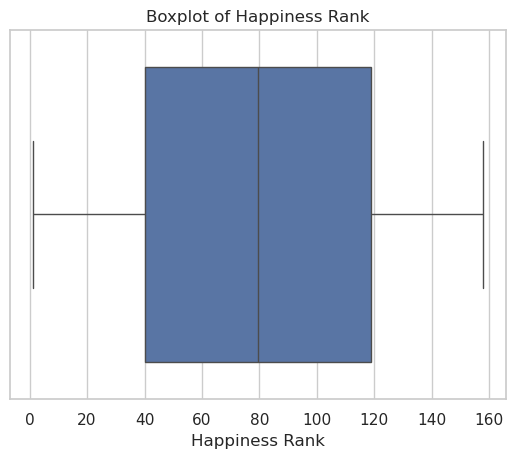

In [11]:
#BOXPLOT
sns.boxplot(x=df[numeric_cols[0]])
plt.title(f"Boxplot of {numeric_cols[0]}")
plt.xlabel(numeric_cols[0])
plt.show()

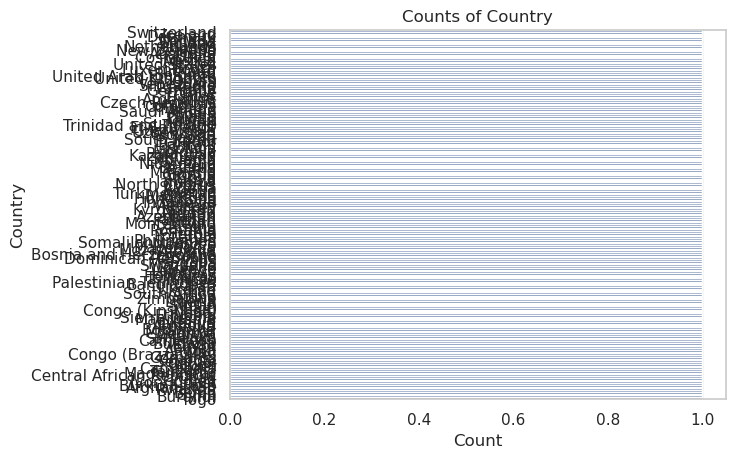

In [12]:
#BAR CHART
sns.countplot(y=df[cat_col], order=df[cat_col].value_counts().index)
plt.title(f"Counts of {cat_col}")
plt.xlabel("Count")
plt.ylabel(cat_col)
plt.show()

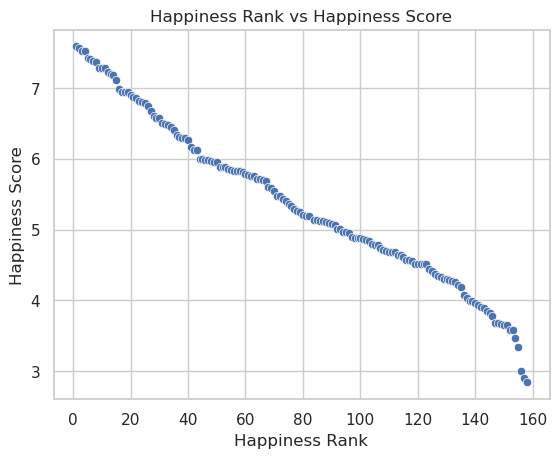

In [13]:
#Scatterpkot

if len(numeric_cols) >= 2:
    sns.scatterplot(
        x=df[numeric_cols[0]],
        y=df[numeric_cols[1]]
    )
    plt.title(f"{numeric_cols[0]} vs {numeric_cols[1]}")
    plt.xlabel(numeric_cols[0])
    plt.ylabel(numeric_cols[1])
    plt.show()

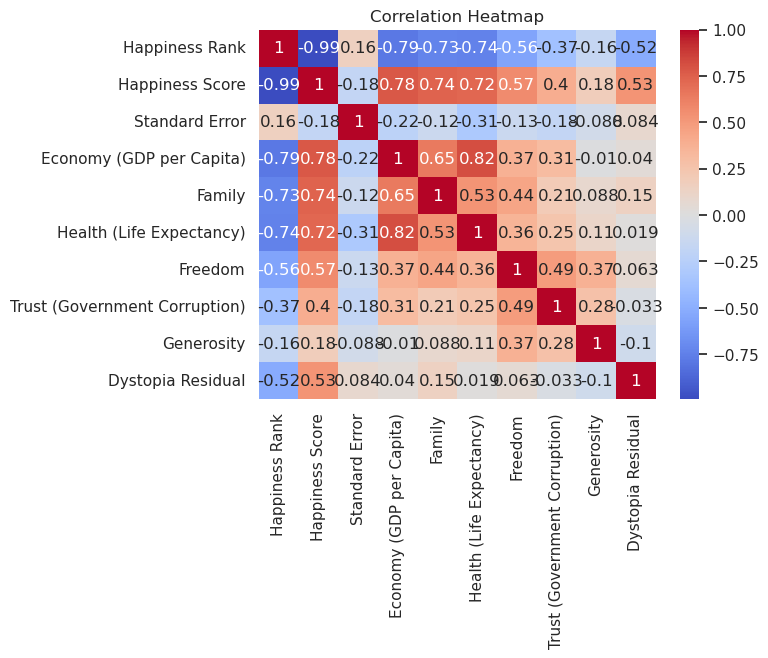

In [14]:
#Heatmap
corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [17]:
insights = []

# Missingness
if high_missing.shape[0] > 0:
    insights.append(
        f"{len(high_missing)} columns have more than 50% missing values, which may limit analysis reliability."
    )

# Outliers
for col in numeric_cols[:2]:
    stats = numeric_summary(df[col].dropna())
    if stats["outliers_1.5IQR"] > 0:
        insights.append(
            f"{col} contains {stats['outliers_1.5IQR']} potential outliers based on the 1.5×IQR rule."
        )

# Correlation
if len(numeric_cols) >= 2:
    max_corr = corr.abs().unstack().sort_values(ascending=False)
    max_corr = max_corr[max_corr < 1].idxmax()
    insights.append(
        f"{max_corr[0]} and {max_corr[1]} show the strongest correlation among numeric variables."
    )

# Categorical dominance
for cat_col in categorical_cols:
    cat_counts = df[cat_col].value_counts(dropna=False)
    cat_percent = cat_counts / cat_counts.sum() * 100

    # Categorical dominance
    top_cat = cat_counts.idxmax()
    insights.append(
        f"The most common value in {cat_col} is '{top_cat}', representing {cat_percent[top_cat]:.1f}% of records."
    )

for i, insight in enumerate(insights[:10], 1):
    print(f"{i}. {insight}")


1. Happiness Rank and Happiness Score show the strongest correlation among numeric variables.
2. The most common value in Country is 'Switzerland', representing 0.6% of records.
3. The most common value in Region is 'Sub-Saharan Africa', representing 25.3% of records.


In [16]:
limitations = [
    "Missing data may bias summary statistics and correlations.",
    "Outlier detection is based solely on the 1.5×IQR rule and may flag valid extreme values.",
    "No external validation or ground truth is available to assess data accuracy.",
    "If the dataset is observational, correlations do not imply causation."
]

for item in limitations:
    print("-", item)

- Missing data may bias summary statistics and correlations.
- Outlier detection is based solely on the 1.5×IQR rule and may flag valid extreme values.
- No external validation or ground truth is available to assess data accuracy.
- If the dataset is observational, correlations do not imply causation.
